# Least Square Method - Gradient Descent - Stochastic Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Least Square Method

In [2]:
# Given data
x = np.array([0.5, 2.3, 2.9])  # weights
y = np.array([1.4, 1.9, 3.2])  # heights

Optimal weights: 0.6410256410256409, Optimal bias: 0.9487179487179498


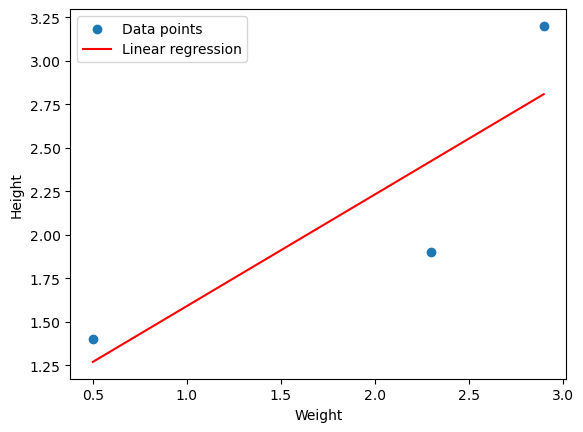

In [3]:
# Add a column of ones to x for the bias term
X = np.vstack([x, np.ones_like(x)]).T

# Use least squares to fit a linear model
m, c = np.linalg.lstsq(X, y, rcond=None)[0]

# Print the results
print(f"Optimal weights: {m}, Optimal bias: {c}")

# Plot the data and the linear regression line
plt.scatter(x, y, label='Data points')
plt.plot(x, m*x + c, color='red', label='Linear regression')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend()
plt.show()


In [5]:
X

array([[0.5, 1. ],
       [2.3, 1. ],
       [2.9, 1. ]])

# Using least square method to find the optimal value for slope and intercept (m and c)


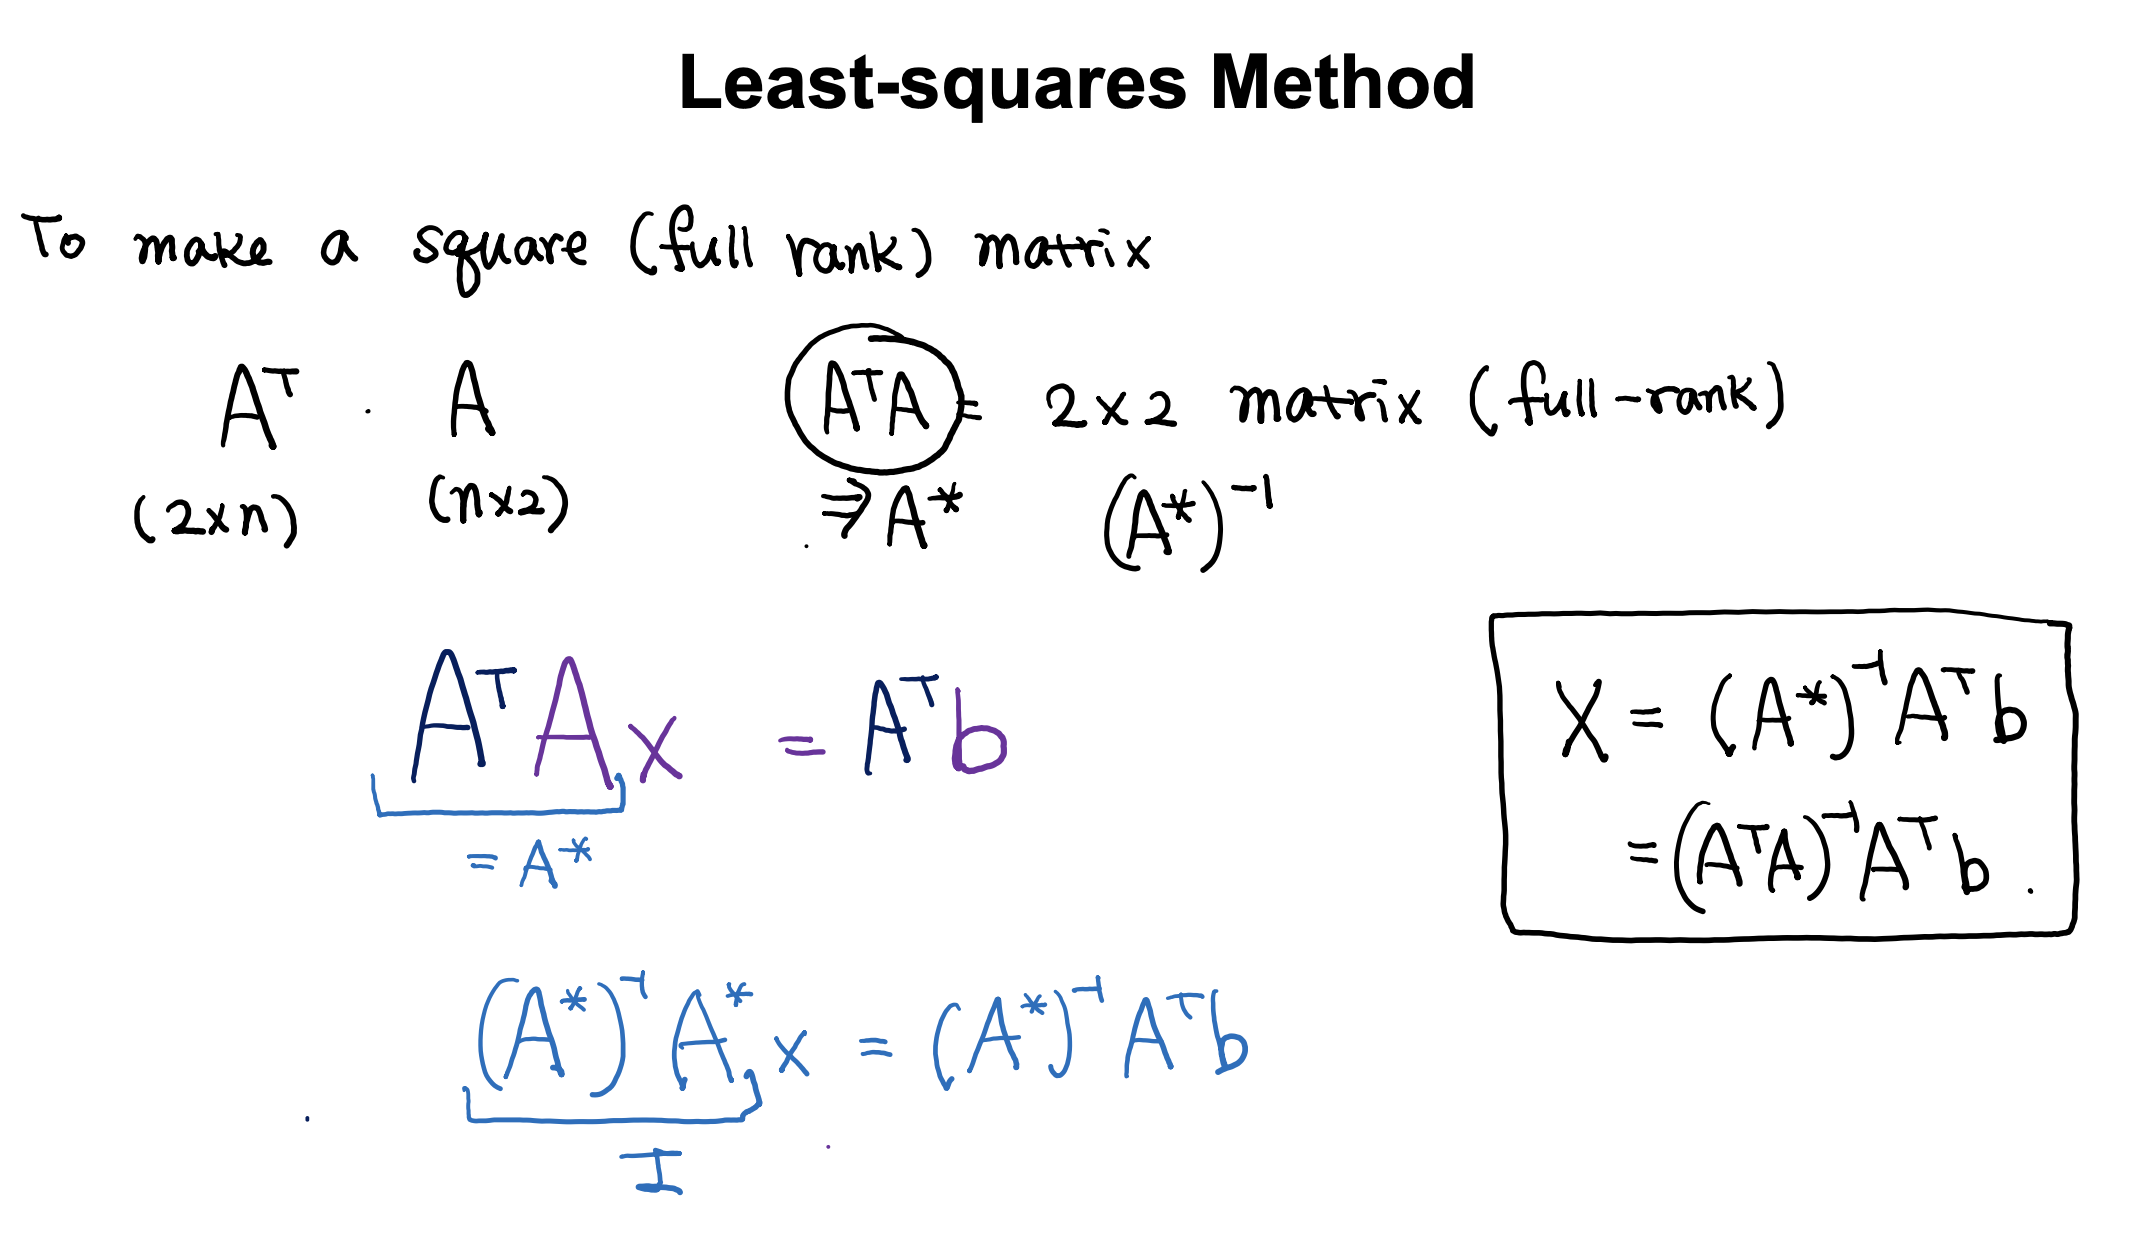

# Reasons for Choosing Gradient Descent over Least Squares:
Scalability: If the dataset is very large, computing the matrix operations involved in the least squares method can become computationally expensive, whereas gradient descent can be more scalable.
Non-linear Relationships: Gradient descent can be extended to handle non-linear relationships, making it more flexible for a broader range of machine learning models.

# Gradient Descent 

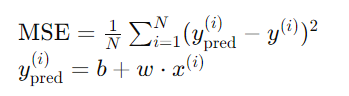

dw: Partial Derivative with Respect to Slope w

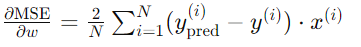

db: Partial Derivative with Respect to Intercept b

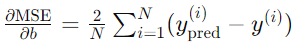

In [4]:
def sum_squared_error(y_true, y_pred):
    return np.sum((y_pred - y_true)**2)

def first_derivative_w(x, y, y_pred, N):
    derivative_w = 0
    for i in range(N):
        derivative_w += 2 * (y_pred[i] - y[i]) * x[i]
    return derivative_w

def first_derivative_b(y, y_pred, N):
    derivative_b = 0
    for i in range(N):
        derivative_b += 2 * (y_pred[i] - y[i])
    return derivative_b

def gradient_descent(x, y, slope, intercept, learning_rate, epochs):
    N = len(x)
    for epoch in range(epochs):
        
        # Calculate predictions
        y_pred =  intercept + slope * x 
        
        # Calculate gradients or first derivative
        dw = first_derivative_w(x, y, y_pred, N)
        db = first_derivative_b(y, y_pred, N)
        
        # next step
        slope = slope - learning_rate * dw
        intercept = intercept -learning_rate * db
                
        # Calculate and print the mean squared error for monitoring
        SSE = sum_squared_error(y, y_pred)
        print(f"Epoch {epoch + 1}/{epochs}, SSE: {SSE}")
    
    return slope, intercept

slope_initial = 1
intercept_initial = 0
learning_rate = 0.01
epochs = 1000

w_optimal, b_optimal = gradient_descent(x, y, slope_initial, intercept_initial, learning_rate, epochs)

print(f"Optimal weights: {w_optimal}, Optimal bias: {b_optimal}")

Epoch 1/1000, SSE: 1.0599999999999998
Epoch 2/1000, SSE: 1.03112
Epoch 3/1000, SSE: 1.0110554607839997
Epoch 4/1000, SSE: 0.9951361731291349
Epoch 5/1000, SSE: 0.9812468286142118
Epoch 6/1000, SSE: 0.9684274290436092
Epoch 7/1000, SSE: 0.9562404435015484
Epoch 8/1000, SSE: 0.9444846592632793
Epoch 9/1000, SSE: 0.9330657943874046
Epoch 10/1000, SSE: 0.9219379919570668
Epoch 11/1000, SSE: 0.9110773643186286
Epoch 12/1000, SSE: 0.9004700291363901
Epoch 13/1000, SSE: 0.8901066981275086
Epoch 14/1000, SSE: 0.8799802287041358
Epoch 15/1000, SSE: 0.8700845153645075
Epoch 16/1000, SSE: 0.8604139869023921
Epoch 17/1000, SSE: 0.8509633775788706
Epoch 18/1000, SSE: 0.8417276222031169
Epoch 19/1000, SSE: 0.8327018072730737
Epoch 20/1000, SSE: 0.8238811474965043
Epoch 21/1000, SSE: 0.8152609738195908
Epoch 22/1000, SSE: 0.806836726689602
Epoch 23/1000, SSE: 0.7986039517143122
Epoch 24/1000, SSE: 0.7905582964345471
Epoch 25/1000, SSE: 0.7826955076287929
Epoch 26/1000, SSE: 0.7750114288864826
Epoch 2

# Steps for Gradient Descent

Main aim is to find the optimal slope and intercept that gives us the best fitting line considering all SSE of all elements in each step

y = mx + c

m = slope
c = intercept

Step 1: Find the gradient or  derivative of cost function - Sum of Squared Resudial/Error w.r.t each parameter i.e, w.r.t slope and intercept 

Step 2: Find the next step or next optimal value for slope and intercept

Srep 3: Repeat from step 1 until the step size (learning_rate * dw) |anew - aold|< e is very small or maximum number of iterations

# Reasons for Choosing Stochastic Gradient Descent over Gradient Descent:

Scalability: If the number of features is very large, computing the SSE will be a costly operation (230000 features , 1000000 samples = 230000000000 times) 

Stochastic Gradient Descent considers one sample randomly and calcu,ates Squared error instead of SSE which considers all the samples to decide next step.


# Stochastic Gradient Descent 

In [6]:
def sum_squared_error(y_true, y_pred):
    return np.sum((y_pred - y_true) ** 2)

def first_derivative_w(x, y, y_pred): 
    return 2 * (y_pred - y) * x

def first_derivative_b(y, y_pred):
    return 2 * (y_pred - y)

def gradient_descent(x, y, slope, intercept, learning_rate, epochs):
    N = len(x)
    for epoch in range(epochs):
        for i in range(N):
            # Select a random data point
            random_index = np.random.randint(N)
            x_i = x[random_index]
            y_i = y[random_index]

            # Calculate predictions
            y_pred = intercept + slope * x_i

            # Calculate gradients or first derivative
            dw = first_derivative_w(x_i, y_i, y_pred)
            db = first_derivative_b(y_i, y_pred)

            # Update step
            slope -= learning_rate * dw
            intercept -= learning_rate * db

        # Calculate and print the mean squared error for monitoring
        y_preds = intercept + slope * x  # Recompute predictions for all x
        SSE = sum_squared_error(y, y_preds)
        print(f"Epoch {epoch + 1}/{epochs}, SSE: {SSE}")

    return slope, intercept

slope_initial = 1
intercept_initial = 0
learning_rate = 0.01
epochs = 5000

w_optimal, b_optimal = gradient_descent(x, y, slope_initial, intercept_initial, learning_rate, epochs)

print(f"Optimal weights: {w_optimal}, Optimal bias: {b_optimal}")


Epoch 1/5000, SSE: 1.0358219102757067
Epoch 2/5000, SSE: 1.0120446684053903
Epoch 3/5000, SSE: 0.9988200139098464
Epoch 4/5000, SSE: 1.0029521737768217
Epoch 5/5000, SSE: 0.9867635573118569
Epoch 6/5000, SSE: 0.9905520449050084
Epoch 7/5000, SSE: 0.963833754968332
Epoch 8/5000, SSE: 0.9780983570056703
Epoch 9/5000, SSE: 0.9494247130019475
Epoch 10/5000, SSE: 0.9384782593991778
Epoch 11/5000, SSE: 0.931446155639999
Epoch 12/5000, SSE: 0.9252809145834084
Epoch 13/5000, SSE: 0.9265062845538408
Epoch 14/5000, SSE: 0.9106500173333614
Epoch 15/5000, SSE: 0.9126518070222333
Epoch 16/5000, SSE: 0.9094417466013488
Epoch 17/5000, SSE: 0.8943781857925852
Epoch 18/5000, SSE: 0.872236511892033
Epoch 19/5000, SSE: 0.8970615109427055
Epoch 20/5000, SSE: 0.866149372991758
Epoch 21/5000, SSE: 0.9037630684180966
Epoch 22/5000, SSE: 0.9441101942329995
Epoch 23/5000, SSE: 0.97401705351714
Epoch 24/5000, SSE: 0.8119537405562504
Epoch 25/5000, SSE: 0.8012045810197557
Epoch 26/5000, SSE: 0.7918511319829998
E

# Steps for Stochastic Gradient Descent

Main aim is to find the optimal slope and intercept that gives us the best fitting line considering one random sample in each step

Step 1: Select a random sample

Step 2: Find the gradient or  derivative of cost function - Squared Resudial/Error w.r.t each parameter i.e, w.r.t slope and intercept 

Step 3: Find the next step or next optimal value for slope and intercept

Srep 4: Repeat from step 1 until the step size (learning_rate * dw) |anew - aold|< e is very small or maximum number of iterations